# Haar Cascade Face & Eye Detection 

**Aim**

To detect human faces and eyes in images and video streams using Haar Cascade classifiers by performing image acquisition, grayscale conversion, feature detection, parameter tuning, and evaluating the effect of face rotation on detection accuracy.

In [1]:
import matplotlib.pyplot as plt

def show(img, title="Image"):
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


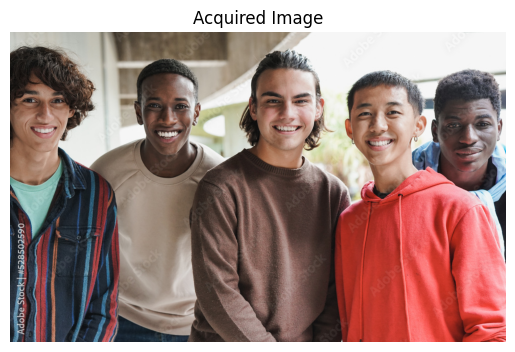

In [3]:
import cv2

frame = cv2.imread("Group.jpg")

cv2.imwrite("acquired_image.jpg", frame)
show(frame, "Acquired Image")




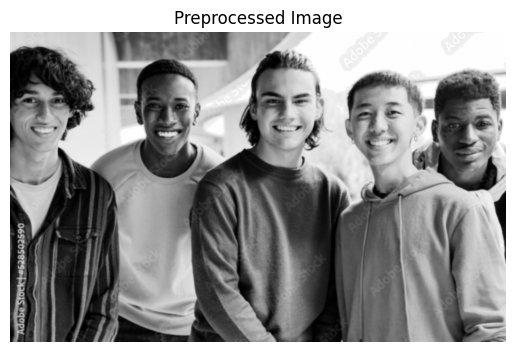

True

In [4]:
img = cv2.imread("acquired_image.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
equalized = cv2.equalizeHist(blur)

show(equalized, "Preprocessed Image")

cv2.imwrite("preprocessed.jpg", equalized)


In [5]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)


## Parameter Effects in Haar Cascade Detection

### scaleFactor
| scaleFactor | Effect                               |
| ----------- | ------------------------------------ |
| 1.05        | Very accurate, slow, more detections |
| 1.1         | **Balanced (used in this practical)** |
| 1.3         | Faster, may miss small faces         |

### minNeighbors
| minNeighbors | Effect                                |
| ------------ | ------------------------------------- |
| 3            | More detections, more false positives |
| 5            | **Stable detection (used in this practical)** |
| 8            | Very strict, fewer detections         |

### minSize
| minSize  | Effect                             |
| -------- | ---------------------------------- |
| (20,20) | Detects small faces, more noise    |
| (40,40) | **Cleaner output (used in this practical)** |
| (80,80) | Misses small faces                 |


Faces detected: 5


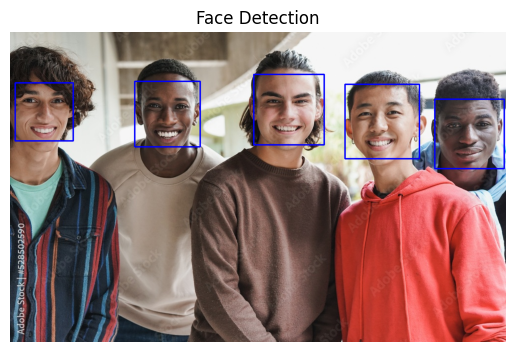

In [15]:
img = cv2.imread("acquired_image.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.2,
    minNeighbors=6,
    minSize=(40, 40)
)

print("Faces detected:", len(faces))

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,0), 2)

show(img, "Face Detection")


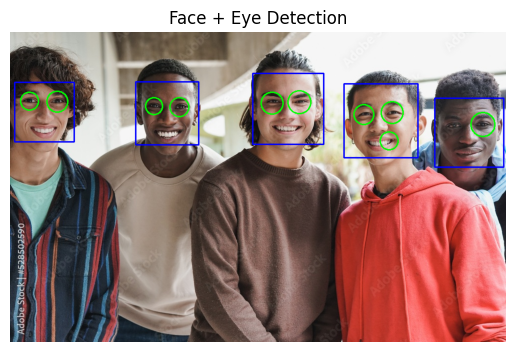

In [26]:
import cv2

# Load image
img = cv2.imread("acquired_image.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Face detection
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=7,
    minSize=(50, 50)
)

# Draw faces and detect eyes
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

    roi_gray = gray[y:y + h, x:x + w]
    roi_color = img[y:y + h, x:x + w]

    # Eye detection (improved)
    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(30, 30)
    )

    for (ex, ey, ew, eh) in eyes:
        cv2.circle(
            roi_color,
            (int(ex + ew / 2), int(ey + eh / 2)),
            int(ew / 2),
            (0, 255, 0),
            2
        )

# Display result
show(img, "Face + Eye Detection")


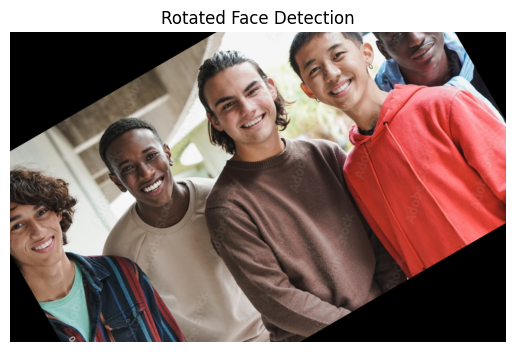

In [32]:
import numpy as np

# Load original image
img = cv2.imread("acquired_image.jpg")

# Rotate image by 30 degrees
(h, w) = img.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, 30, 1.0)
rotated = cv2.warpAffine(img, M, (w, h))

gray_rot = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)

faces_rot = face_cascade.detectMultiScale(
    gray_rot,
    scaleFactor=2.5,
    minNeighbors=7,
    minSize=(30, 30)
)

for (x, y, w, h) in faces_rot:
    cv2.rectangle(rotated, (x, y), (x + w, y + h), (255, 0, 0), 2)

show(rotated, "Rotated Face Detection")


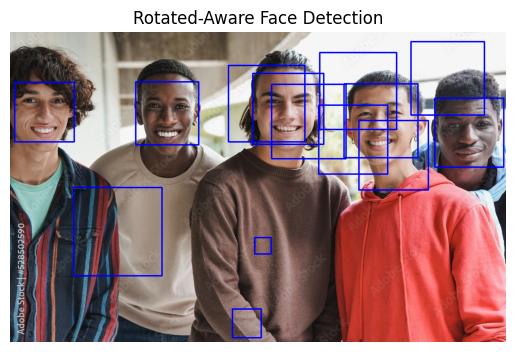

In [36]:
import cv2
import numpy as np

img = cv2.imread("acquired_image.jpg")
(h, w) = img.shape[:2]
center = (w // 2, h // 2)

angles = [-30, -15, 0, 15, 30]

output = img.copy()

for angle in angles:
    # Rotate image
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h))
    gray = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(20, 20)
    )

    for (x, y, fw, fh) in faces:
        # Transform box back to original image
        cv2.rectangle(
            output,
            (x, y),
            (x + fw, y + fh),
            (255, 0, 0),
            2
        )

show(output, "Rotated-Aware Face Detection")


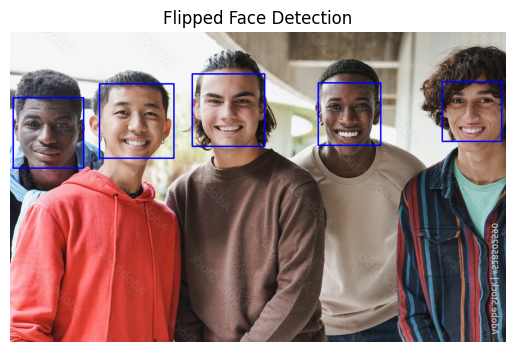

In [35]:
flipped = cv2.flip(img, 1)
gray = cv2.cvtColor(flipped, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.1, 7)

for (x,y,w,h) in faces:
    cv2.rectangle(flipped, (x,y), (x+w,y+h), (255,0,0), 2)

show(flipped, "Flipped Face Detection")


**Observation**

1. The Haar Cascade classifier successfully detected human faces in frontal and near-frontal images.

2. In group photographs, multiple faces were correctly identified and bounded using rectangular boxes.

3. Eye detection within the detected face regions was achieved using region of interest (ROI) based processing.

4. Parameter tuning using scaleFactor, minNeighbors, and minSize improved detection accuracy and reduced false positives.

5. When the image was rotated, the face detection accuracy reduced significantly, and few or no faces were detected.

6. Partial detection of rotated faces was possible by applying multi-angle detection, demonstrating limited robustness to rotation.

**Conclusion**

* Haar Cascade classifiers are effective and computationally efficient for real-time frontal face and eye detection.

* The algorithm performs well under good lighting conditions and for upright facial orientations.

* However, Haar Cascades are sensitive to pose variations such as face rotation and occlusion.

* While basic rotation handling can be achieved through multi-angle detection, Haar Cascades are not inherently rotation-invariant.

* For robust face detection under complex conditions, advanced methods such as deep learning-based detectors are preferred.


by Roy